In [1]:
from google.colab import files
uploaded = files.upload()

Saving UWOC_useing_photoresistor-main.zip to UWOC_useing_photoresistor-main.zip


In [3]:
import zipfile
import io

# Assuming the uploaded file is in the 'uploaded' dictionary
zip_file_name = 'UWOC_useing_photoresistor-main.zip'

# Unzip the file
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    z.extractall('.')
print(f"Extracted {zip_file_name} contents.")

Extracted UWOC_useing_photoresistor-main.zip contents.


In [4]:
import pandas as pd

df = pd.read_csv('UWOC_useing_photoresistor-main/anaotherGUI/1-2NTU.csv')
print(df.shape)
df.head()

(8512, 3)


,labels,feature,bit
0,0,0.346680,0
1,0,0.346680,0
2,0,0.346680,0
3,1,0.532227,1
4,0,0.346680,0


In [5]:
# Check for missing values
print(df.isnull().sum())

# Check class balance
print(df['labels'].value_counts())

# Basic stats on the feature column
print(df['feature'].describe())

labels     0
feature    0
bit        0
dtype: int64
labels
0    5321
1    3191
Name: count, dtype: int64
count    8512.000000
mean        0.416311
std         0.087772
min         0.336914
25%         0.346680
50%         0.351562
75%         0.527344
max         0.625000
Name: feature, dtype: float64


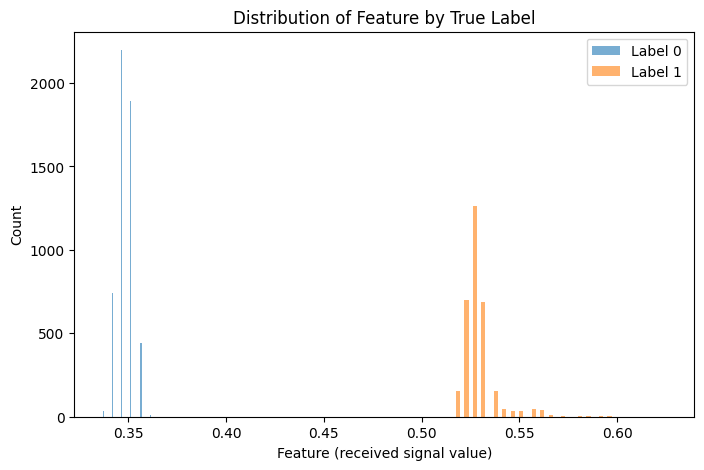

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df[df['labels']==0]['feature'], bins=50, alpha=0.6, label='Label 0')
plt.hist(df[df['labels']==1]['feature'], bins=50, alpha=0.6, label='Label 1')
plt.xlabel('Feature (received signal value)')
plt.ylabel('Count')
plt.title('Distribution of Feature by True Label')
plt.legend()
plt.show()

In [7]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Simple fixed threshold, right in the gap
threshold = 0.44
df['threshold_pred'] = (df['feature'] > threshold).astype(int)

acc = accuracy_score(df['labels'], df['threshold_pred'])
f1 = f1_score(df['labels'], df['threshold_pred'])
cm = confusion_matrix(df['labels'], df['threshold_pred'])

print("Accuracy:", acc)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[5321    0]
 [   0 3191]]


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['feature']]
y = df['labels']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression F1:", f1_score(y_test, y_pred))

Logistic Regression Accuracy: 1.0
Logistic Regression F1: 1.0
